In [1]:
import numpy as np 
import pandas as pd
import os
from readData import *
from baryonFit import HernquistFit, DehnenFit

import matplotlib.pyplot as plt

# Get all galaxy ids

In [2]:
galaxy_ids = get_galaxy_ids()

# Generate all lmfit fits assuming gamma = 0.5

In [21]:
plot_path = os.getcwd() + "/plots/fits/"
data_path = os.getcwd() + "/data/fit_data/"

results = []
failed = []

for galaxy_id in galaxy_ids:
    try:
        fitter = HernquistFit(galaxy_id, gamma_star=0.5, method="lmfit")
        M_b_fit, a_fit = fitter.M_b_fit, fitter.a_fit
        chisqr = fitter.result.chisqr
        redchisqr = fitter.result.redchi
    except Exception as e:
        failed.append(galaxy_id)
        print(f"Error fitting galaxy {galaxy_id}. Skipping...")
        continue
    
    results.append([galaxy_id, M_b_fit, a_fit, chisqr, redchisqr])
    
    rmax = fitter.r_vals.max() * 2 # kpc
    r_vals = np.geomspace(0.1, rmax, 100)
    vc_fit = fitter.vc(r_vals)
    
    plt.figure(figsize=(6,4))
    plt.plot(r_vals, vc_fit, label='Hernquist Fit', color='C0', alpha=0.7, zorder=0)
    plt.errorbar(fitter.r_vals, fitter.vc_baryons, yerr=fitter.data["errV"], fmt='o', label='Data', color='k', zorder=1, markersize=4, alpha=0.5)
    plt.xlabel('Radius [kpc]')
    plt.ylabel('Circular Velocity [km/s]')
    plt.title(f'Galaxy {galaxy_id} Hernquist Fit')
    plt.legend()
    plt.savefig(os.path.join(plot_path, f"{galaxy_id}_hernquist_fit.png"))
    plt.close()
    
    
results_df = pd.DataFrame(results, columns=["GalaxyID", "M_b_fit", "a_fit", "ChiSq", "RedChiSq"])
results_df.to_csv(os.path.join(data_path, "hernquist_fit_results.csv"), index=False)
print("Fitting complete. Results saved.")
np.savetxt(os.path.join(data_path, "failed_fits.txt"), failed, fmt="%s")
    

Fitting with lmfit took 0.0110 seconds
Fitted parameters for galaxy NGC5371 using lmfit:
  M_b = 3.93e+11 solar masses
  a   = 10.53 kpc
  chi-squared = 6127.4849


Fitting with lmfit took 0.3429 seconds
Fitted parameters for galaxy UGC05829 using lmfit:
  M_b = 1.13e+21 solar masses
  a   = 5497424.38 kpc
  chi-squared = 185.9626
Fitting with lmfit took 0.0151 seconds
Fitted parameters for galaxy NGC5005 using lmfit:
  M_b = 1.48e+11 solar masses
  a   = 2.37 kpc
  chi-squared = 2086.7819
Error fitting galaxy UGCA444 with lmfit: The model function generated NaN values and the fit aborted! Please check your model function and/or set boundaries on parameters where applicable. In cases like this, using "nan_policy='omit'" will probably not work.
Fitting with lmfit took 0.0034 seconds
Error fitting galaxy UGCA444. Skipping...
Fitting with lmfit took 0.0068 seconds
Fitted parameters for galaxy NGC1003 using lmfit:
  M_b = 1.22e+10 solar masses
  a   = 4.40 kpc
  chi-squared = 264.3338
Error fitting galaxy UGC07559 with lmfit: The model function generated NaN values and the fit aborted! Please check your model function and/or set boundaries on paramete

# Generate lmfit with Gamma Fits 

In [3]:
plot_path = os.getcwd() + "/plots/fits/"
data_path = os.getcwd() + "/data/fit_data/"

gamma_data = pd.read_csv(data_path + "gamma_fits.csv")

results = []
failed = []

for galaxy_id in galaxy_ids:
    gamma_s, gamma_b = gamma_data[gamma_data["GalaxyID"] == galaxy_id][["Gamma_disk", "Gamma_bulge"]].values[0]
    try:
        # Set gamma_bulge = 0 
        fitter = HernquistFit(galaxy_id, gamma_star=gamma_s, gamma_bulge=0.0, method="lmfit")
        M_b_fit, a_fit = fitter.M_b_fit, fitter.a_fit
        chisqr = fitter.result.chisqr
        redchisqr = fitter.result.redchi
    except Exception as e:
        failed.append(galaxy_id)
        print(f"Error fitting galaxy {galaxy_id}. Skipping...")
        continue
    
    results.append([galaxy_id, M_b_fit, a_fit, chisqr, redchisqr])
    
    rmax = fitter.r_vals.max() * 2 # kpc
    r_vals = np.geomspace(0.1, rmax, 100)
    vc_fit = fitter.vc(r_vals)
    
    # plt.figure(figsize=(6,4))
    # plt.plot(r_vals, vc_fit, label='Hernquist Fit', color='C0', alpha=0.7, zorder=0)
    # plt.errorbar(fitter.r_vals, fitter.vc_baryons, yerr=fitter.data["errV"], fmt='o', label='Data', color='k', zorder=1, markersize=4, alpha=0.5)
    # plt.xlabel('Radius [kpc]')
    # plt.ylabel('Circular Velocity [km/s]')
    # plt.title(f'Galaxy {galaxy_id} Hernquist Fit')
    # plt.legend()
    # plt.savefig(os.path.join(plot_path, f"{galaxy_id}_hernquist_fit.png"))
    # plt.close()
    
    
results_df = pd.DataFrame(results, columns=["GalaxyID", "M_b_fit", "a_fit", "ChiSq", "RedChiSq"])
results_df.to_csv(os.path.join(data_path, "hernquist_fit_disk_gas.csv"), index=False)
print("Fitting complete. Results saved.")
np.savetxt(os.path.join(data_path, "failed_fits_gamma.txt"), failed, fmt="%s")

Fitting with lmfit took 0.0211 seconds
Fitted parameters for galaxy NGC5371 using lmfit:
  M_b = 3.38e+11 solar masses
  a   = 10.72 kpc
  chi-squared = 5220.8497
Fitting with lmfit took 0.3205 seconds
Fitted parameters for galaxy UGC05829 using lmfit:
  M_b = 1.14e+21 solar masses
  a   = 5515868.85 kpc
  chi-squared = 182.8182
Fitting with lmfit took 0.0137 seconds
Fitted parameters for galaxy NGC5005 using lmfit:
  M_b = 3.04e+11 solar masses
  a   = 7.39 kpc
  chi-squared = 1667.2293
Error fitting galaxy UGCA444 with lmfit: The model function generated NaN values and the fit aborted! Please check your model function and/or set boundaries on parameters where applicable. In cases like this, using "nan_policy='omit'" will probably not work.
Fitting with lmfit took 0.0086 seconds
Fitted parameters for galaxy UGCA444 using lmfit:
  M_b = nan solar masses
  a   = nan kpc
  chi-squared = nan
Error fitting galaxy UGCA444. Skipping...
Fitting with lmfit took 0.0056 seconds
Fitted parameters

# Generate lmfit with Gamma and Bulge 

In [3]:
bulge_list = []

for gal in galaxy_ids:
    df, _, _ = get_rc_data(gal)
    vbul = df.Vbul.values 
    
    if np.any(vbul > 0):
        bulge_list.append(gal)

print("Total number of galaxies:", len(galaxy_ids))
print("Number of galaxies with bulge component:", len(bulge_list))
print("Galaxies with bulge component:", bulge_list)

Total number of galaxies: 175
Number of galaxies with bulge component: 32
Galaxies with bulge component: ['NGC5005', 'NGC6195', 'UGC08699', 'NGC2841', 'NGC5985', 'UGC05253', 'UGC03546', 'NGC6946', 'UGC06614', 'NGC5033', 'UGC02885', 'UGC06973', 'UGC02487', 'NGC2683', 'NGC7814', 'UGC11914', 'NGC0891', 'UGC06787', 'NGC2955', 'UGC03580', 'UGC06786', 'NGC6674', 'UGC09133', 'UGC02953', 'NGC4138', 'IC4202', 'NGC4013', 'UGC03205', 'NGC7331', 'UGC02916', 'NGC4217', 'NGC4157']


In [17]:
plot_path = os.getcwd() + "/plots/fits/"
data_path = os.getcwd() + "/data/fit_data/"

gamma_data = pd.read_csv(data_path + "gamma_fits.csv")

results = []
failed = []

for galaxy_id in galaxy_ids: 
    gamma_s, gamma_b = gamma_data[gamma_data["GalaxyID"] == galaxy_id][["Gamma_disk", "Gamma_bulge"]].values[0]
    try:
        fitter = HernquistFit(galaxy_id, gamma_star=gamma_s, gamma_bulge=gamma_b, method="lmfit")
        M_b_fit, a_fit = fitter.M_b_fit, fitter.a_fit
        chisqr = fitter.error
        
        M_b_fit_b, a_fit_b = fitter.M_b_fit_bulge, fitter.a_fit_bulge
        chisqr_b = fitter.error_bulge
    except Exception as e:
        failed.append(galaxy_id)
        print(f"Error fitting galaxy {galaxy_id}. Skipping...")
        continue
    
    results.append([galaxy_id, M_b_fit, a_fit, chisqr, M_b_fit_b, a_fit_b, chisqr_b])
    
    # r_vals = fitter.r_vals
    # rmax = r_vals.max() * 2 # kpc
    # ri = np.geomspace(0.1, rmax, 100)
    
    # vc_dg_data = fitter.vc_disk_gas
    # vc_bulge_data = fitter.vc_bulge
    
    # vc_dg_model = fitter.vc(ri, M_b=M_b_fit, a=a_fit)
    # vc_bulge_model = fitter.vc(ri, M_b=M_b_fit_b, a=a_fit_b)
    
    
    # plt.figure(figsize=(6,4))

    # plt.scatter(r_vals, vc_dg_data, label='Disk+Gas', color='C0', s=10)
    # plt.plot(ri, vc_dg_model, label='Disk+Gas Hernquist', color='C0', alpha=0.7)
    # plt.scatter(r_vals, vc_bulge_data, label='Bulge', color='C1', s=10)
    # plt.plot(ri, vc_bulge_model, label='Bulge Hernquist', color='C1', alpha=0.7)
    # plt.xlabel('Radius (kpc)')
    # plt.ylabel('Velocity (km/s)')
    # plt.title(f'Hernquist Fit for Galaxy {galaxy_id}')
    # plt.legend(fontsize=6, loc="lower right")
    # plt.grid()
    # plt.savefig(plot_path + f"disk-bulge-gas/{galaxy_id}_disk_gas_bulge_fit.png")
    # plt.close()
    
    
results_df = pd.DataFrame(results, columns=["GalaxyID", "M_b_fit", "a_fit", "ChiSq", "M_b_fit_bulge", "a_fit_bulge", "ChiSq_bulge"])
results_df.to_csv(os.path.join(data_path, "hern_fits.csv"), index=False)
print("Fitting complete. Results saved.")
# np.savetxt(os.path.join(data_path, "hern-failed.txt"), failed, fmt="%s")
print("Number of failed fits:", len(failed))

Fitting with lmfit took 0.0176 seconds
Fitted parameters for galaxy NGC5371 using lmfit:
  M_b = 3.38e+11 solar masses
  a   = 10.72 kpc
  chi-squared = 5220.8497
Fitting with lmfit took 0.0162 seconds
Fitted parameters for galaxy UGC05829 using lmfit:
  M_b = 4.09e+11 solar masses
  a   = 100.00 kpc
  chi-squared = 218.9158
Fitting with lmfit took 0.0078 seconds
Fitted parameters for galaxy NGC5005 using lmfit:
  M_b = 3.04e+11 solar masses
  a   = 7.39 kpc
  chi-squared = 1667.2293
Bulge component detected, performing separate fit for bulge...
Fitting with lmfit took 0.0121 seconds
Fitted parameters for galaxy NGC5005 using lmfit:
  M_b = 1.50e+10 solar masses
  a   = 0.41 kpc
  chi-squared = 1970.0142
Fitting with lmfit took 0.0074 seconds
Fitted parameters for galaxy UGCA444 using lmfit:
  M_b = 6.69e+09 solar masses
  a   = 13.21 kpc
  chi-squared = 133.6809
Fitting with lmfit took 0.0061 seconds
Fitted parameters for galaxy NGC1003 using lmfit:
  M_b = 1.38e+10 solar masses
  a  

In [12]:
def phi(M_b, a):
    G = 4.30091e-6  # [kpc * (km/s)^2/ solar mass]

    def phi_func(r, th):
        return -G * M_b / (r + a)

    return phi_func

In [13]:
bulge_data = pd.read_csv(data_path + "hernquist_fits_disk_gas_bulge.csv")

bulge_ids = bulge_data["GalaxyID"].values

for bul in bulge_ids:
    sub = bulge_data[bulge_data["GalaxyID"] == bul]
    M_b_fit = sub["M_b_fit"].values[0]
    a_fit = sub["a_fit"].values[0]
    M_b_fit_bulge = sub["M_b_fit_bulge"].values[0]
    a_fit_bulge = sub["a_fit_bulge"].values[0]
    
    ri = np.geomspace(0.1, 200, 200)
    phi_dg = np.abs(np.array([phi(M_b_fit, a_fit)(r, 0) for r in ri]))
    phi_b  = np.abs(np.array([phi(M_b_fit_bulge, a_fit_bulge)(r, 0) for r in ri]))

    phi_total = phi_dg + phi_b

    percent_diff = 100 * ( np.abs((phi_total - phi_dg)) / np.abs(phi_total) )

    fig, axs = plt.subplots(2, 1, figsize=(6, 4), sharex=True, gridspec_kw={'height_ratios': [3, 1]})


    axs[0].plot(ri, phi_dg, label='Disk+Gas Potential', color='C0')
    axs[0].plot(ri, phi_b, label='Bulge Potential', color='C1')
    axs[0].plot(ri, phi_total, label='Total Baryonic Potential', color='k', linestyle='--')
    axs[0].set_ylabel('-Potential (km^2/s^2)')
    axs[0].set_title(f'Gravitational Potential for Galaxy {bul}')
    axs[0].legend(fontsize=6, loc="lower left")
    axs[0].grid()
    axs[0].set_xscale('log')
    axs[0].set_yscale('log')

    axs[1].plot(ri, percent_diff, label='Percent Difference', color='k')
    axs[1].set_xlabel('Radius (kpc)')
    axs[1].set_ylabel('Diff (%)')
    axs[1].grid()
    axs[1].set_xscale('log')
    # axs[1].set_yscale('log')

    plt.tight_layout()
    plt.savefig(plot_path + f"disk-bulge-gas/{bul}_potential_comparison.png")
    plt.close()
    


In [14]:
bulge_data.columns

Index(['GalaxyID', 'M_b_fit', 'a_fit', 'ChiSq', 'M_b_fit_bulge', 'a_fit_bulge',
       'ChiSq_bulge'],
      dtype='object')

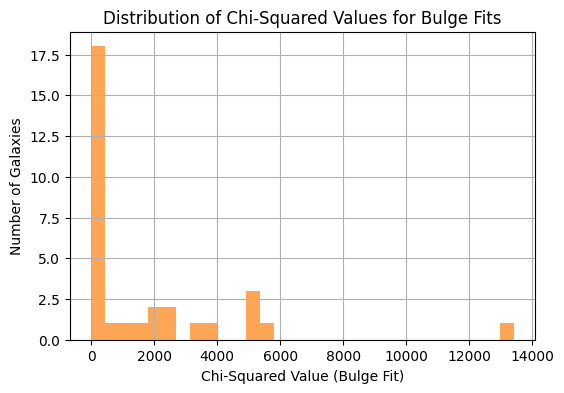

In [27]:
# plot the chisqr values for disk+gas vs bulge fits
plt.figure(figsize=(6,4))

chi2 = bulge_data["ChiSq_bulge"].values
# chi2 = np.where(chi2 > 100, np.nan, chi2)  # Replace zero values with a small number for log scale

plt.hist(chi2, bins=30, color='C1', alpha=0.7)
plt.xlabel('Chi-Squared Value (Bulge Fit)')
plt.ylabel('Number of Galaxies')
plt.title('Distribution of Chi-Squared Values for Bulge Fits')
plt.grid()
# plt.xscale('log')
plt.show()


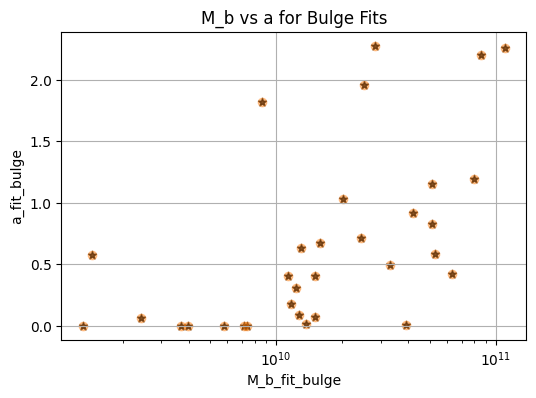

In [17]:
# plot Mb and a for disk gas and bulge fits
bulge_data = pd.read_csv(data_path + "hernquist_fits_disk_gas_bulge.csv")
bulge_data_log = pd.read_csv(data_path + "hernquist_fits_disk_gas_bulge_log.csv")

plt.figure(figsize=(6,4))

plt.scatter(bulge_data["M_b_fit_bulge"].values, bulge_data["a_fit_bulge"].values, color='k', marker='*', alpha=0.8)
plt.scatter(bulge_data_log["M_b_fit_bulge"].values, bulge_data_log["a_fit_bulge"].values, color='C1', alpha=0.4)
plt.xlabel('M_b_fit_bulge')
plt.ylabel('a_fit_bulge')
plt.title('M_b vs a for Bulge Fits')
plt.grid()
plt.xscale('log')
# plt.yscale('log')
plt.show()

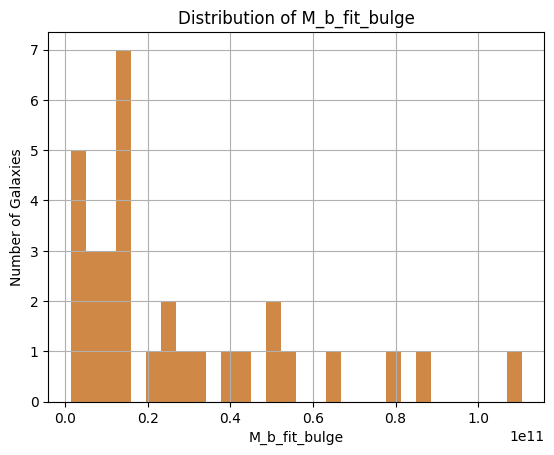

In [11]:
plt.hist(bulge_data["M_b_fit_bulge"].values, bins=30, color='C0', alpha=0.7)
plt.hist(bulge_data_log["M_b_fit_bulge"].values, bins=30, color='C1', alpha=0.7)
plt.xlabel('M_b_fit_bulge')
plt.ylabel('Number of Galaxies')
plt.title('Distribution of M_b_fit_bulge')
plt.grid()
# plt.xscale('log')
plt.show()

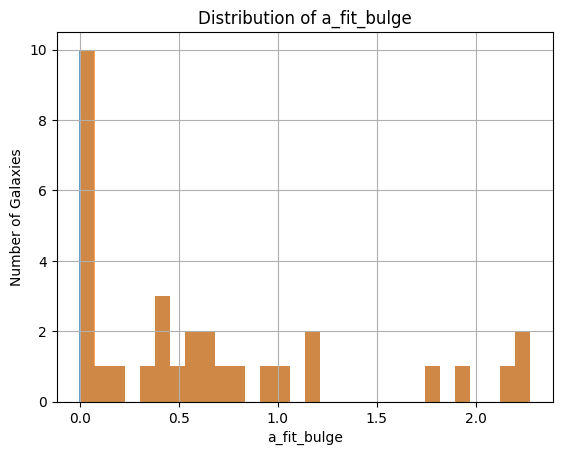

In [12]:
plt.hist(bulge_data["a_fit_bulge"].values, bins=30, color='C0', alpha=0.7)
plt.hist(bulge_data_log["a_fit_bulge"].values, bins=30, color='C1', alpha=0.7)
plt.xlabel('a_fit_bulge')
plt.ylabel('Number of Galaxies')
plt.title('Distribution of a_fit_bulge')
plt.grid()
# plt.xscale('log')
plt.show()

In [6]:
print(len(bulge_data))
print(len(bulge_data_log))

32
32


In [34]:
max_a = bulge_data["a_fit_bulge"].values.max()

gid_max_a = bulge_data[bulge_data["a_fit_bulge"] == max_a]["GalaxyID"].values[0]

print(f"Galaxy with largest a_fit_bulge: {gid_max_a} with a_fit_bulge = {max_a}")

Galaxy with largest a_fit_bulge: NGC4217 with a_fit_bulge = 2.2754076229727467


# Plot the chi squared results

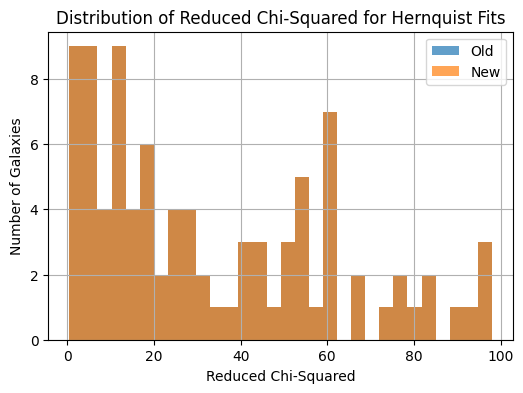

In [7]:
plot_path = os.getcwd() + "/plots/fits/"
data_path = os.getcwd() + "/data/fit_data/"

data = pd.read_csv(os.path.join(data_path, "hern_fits.csv"))
data2 = pd.read_csv(os.path.join(data_path, "hern_fits_test.csv"))
# failed = np.loadtxt(os.path.join(data_path, "failed_fits_gamma.txt"), dtype=str).tolist()
# print("Number of galaxies with failed fits:", len(failed))

sub = data[data["ChiSq"] < 100]
sub2 = data2[data2["ChiSq"] < 100]

plt.figure(figsize=(6,4))
plt.hist(sub["ChiSq"], bins=30, color='C0', alpha=0.7, label='Old')
plt.hist(sub2["ChiSq"], bins=30, color='C1', alpha=0.7, label='New')
plt.legend()  
plt.xlabel('Reduced Chi-Squared')
plt.ylabel('Number of Galaxies')
plt.title('Distribution of Reduced Chi-Squared for Hernquist Fits')
plt.grid()
plt.show()

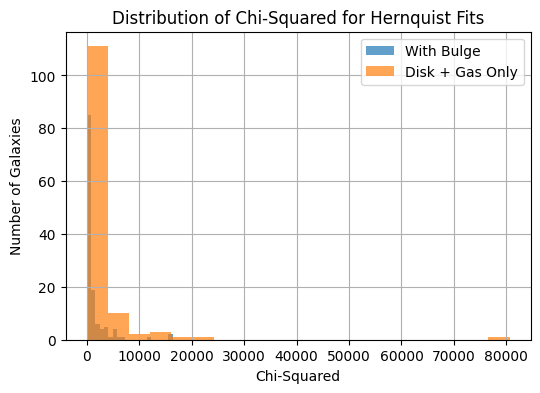

In [5]:
plt.figure(figsize=(6,4))
plt.hist(data["ChiSq"], bins=20, color='C0', alpha=0.7, label='With Bulge')  
plt.hist(data2["ChiSq"], bins=20, color='C1', alpha=0.7, label='Disk + Gas Only')
plt.legend()
plt.xlabel('Chi-Squared')
plt.ylabel('Number of Galaxies')
plt.title('Distribution of Chi-Squared for Hernquist Fits')
plt.grid()
plt.show()

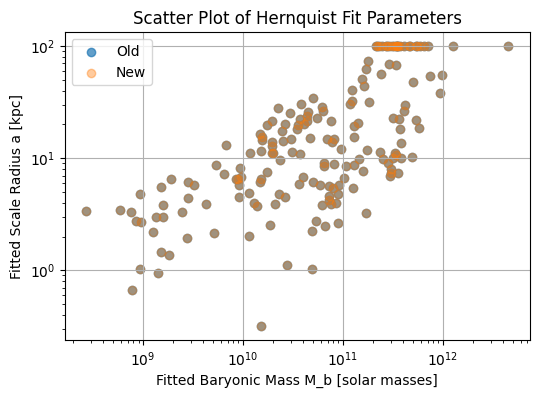

In [8]:
# scatter of M_b and a fits

plt.figure(figsize=(6,4))
plt.scatter(data["M_b_fit"], data["a_fit"], color='C0', alpha=0.7, label='Old')
plt.scatter(data2["M_b_fit"], data2["a_fit"], color='C1', alpha=0.4, label='New')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Fitted Baryonic Mass M_b [solar masses]')
plt.ylabel('Fitted Scale Radius a [kpc]')
plt.title('Scatter Plot of Hernquist Fit Parameters')
plt.legend()
plt.grid()
plt.show()

Check the cluster at high mass

# Mass-to-Light Ratio 

In [ ]:
# path = os.getcwd() + "/data/fit_data/"

# results = []

# for galaxy_id in galaxy_ids:
#     g_disk, e_disk = Gamma_disk(galaxy_id)
#     g_bulg, e_bulg = Gamma_bulge(galaxy_id)
    
#     results.append([galaxy_id, g_disk, e_disk, g_bulg, e_bulg])
    
# results_df = pd.DataFrame(results, columns=["GalaxyID", "Gamma_disk", "Error_disk", "Gamma_bulge", "Error_bulge"])
# results_df.to_csv(os.path.join(path, "gamma_fits.csv"), index=False)

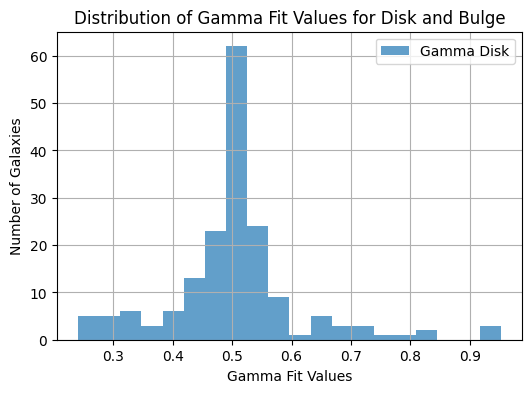

In [14]:
data = pd.read_csv(data_path + "gamma_fits.csv")

plt.figure(figsize=(6,4))
plt.hist(data["Gamma_disk"], bins=20, color='C0', alpha=0.7)
# plt.hist(data["Gamma_bulge"], bins=30, color='C1', alpha=0.7)
plt.xlabel('Gamma Fit Values')
plt.ylabel('Number of Galaxies')
plt.title('Distribution of Gamma Fit Values for Disk and Bulge')
plt.legend(['Gamma Disk', 'Gamma Bulge'])
plt.grid()
plt.show()

In [15]:
len(data)

175

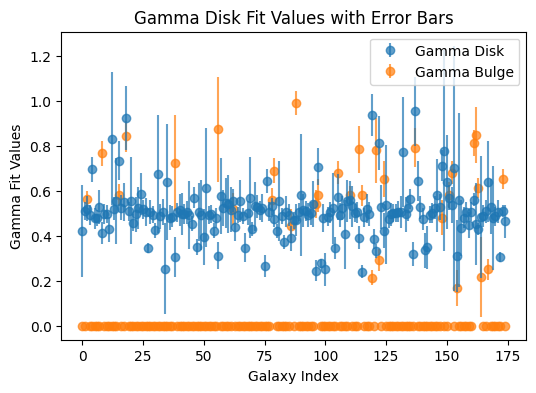

In [5]:
plt.figure(figsize=(6,4))

plt.errorbar(data["GalaxyID"].index, data["Gamma_disk"], yerr=data["Error_disk"], fmt='o', label='Gamma Disk', color='C0', alpha=0.7, zorder=3)
plt.errorbar(data["GalaxyID"].index, data["Gamma_bulge"], yerr=data["Error_bulge"], fmt='o', label='Gamma Bulge', color='C1', alpha=0.7, zorder=0)
plt.ylabel('Gamma Fit Values')
plt.xlabel('Galaxy Index')
plt.title('Gamma Disk Fit Values with Error Bars')
plt.legend()
plt.show()

# Compare M_b from fits and M_b from rotation curve data

In [23]:
hfit = pd.read_csv(data_path + "hern_fits.csv")
dfit = pd.read_csv(data_path + "dehnen_fits.csv")

results = []

for galaxy_id in galaxy_ids:
    try:
        dfh = hfit[hfit["GalaxyID"] == galaxy_id]
        dfd = dfit[dfit["GalaxyID"] == galaxy_id]
        M_b_fit_h = np.log10(dfh["M_b_fit"].values[0])
        M_b_fit_d = np.log10(dfd["M_b_fit"].values[0])
        M_b, err_Mb = get_Mb_data(galaxy_id)
        M_b = np.log10(M_b)
    except:
        continue
    
    results.append((galaxy_id, M_b_fit_h, M_b_fit_d, M_b))
    
results_df = pd.DataFrame(results, columns=["GalaxyID", "log_M_b_fit_hern", "log_M_b_fit_dehnen", "log_M_b"])
results_df.to_csv(os.path.join(data_path, "M_b_comparison.csv"), index=False)

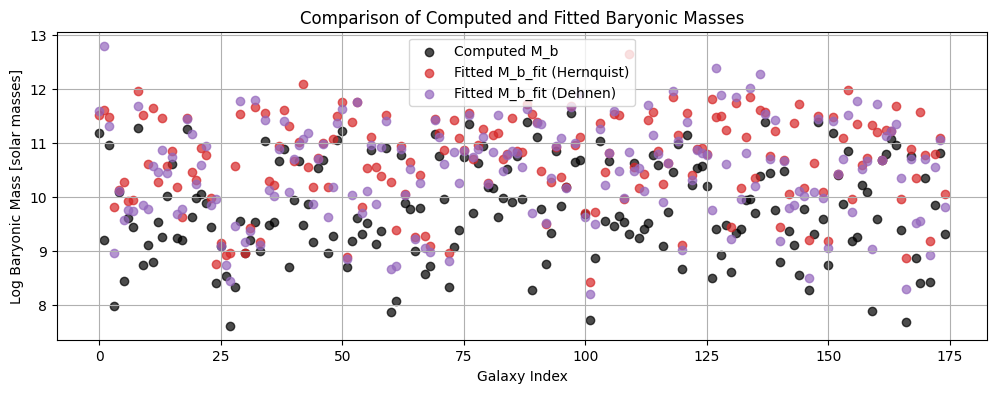

In [24]:
data = pd.read_csv(os.path.join(data_path, "M_b_comparison.csv"))

idx = np.arange(len(data))

plt.figure(figsize=(12,4))
plt.scatter(idx, data["log_M_b"], label='Computed M_b', color='k', alpha=0.7)
plt.scatter(idx, data["log_M_b_fit_hern"], label='Fitted M_b_fit (Hernquist)', color='C3', alpha=0.7)
plt.scatter(idx, data["log_M_b_fit_dehnen"], label='Fitted M_b_fit (Dehnen)', color='C4', alpha=0.7)
plt.xlabel('Galaxy Index')
plt.ylabel('Log Baryonic Mass [solar masses]')
plt.title('Comparison of Computed and Fitted Baryonic Masses')
plt.legend()
plt.grid()
plt.show()

The fitted Masses are consistently higher than the computed. This may be due to the fact that I neglected to include the bulge mass in the computed mass. 

In [16]:
gid_bulge = []
gid_nobulge = []

for galaxy_id in galaxy_ids:
    df, _, _ = get_rc_data(galaxy_id)
    bul = df["Vbul"].values[0]
    if np.sum(bul) > 0:
        gid_bulge.append(galaxy_id)
    else:
        gid_nobulge.append(galaxy_id)
print("Galaxies with bulge:", len(gid_bulge))
print("Galaxies without bulge:", len(gid_nobulge))

Galaxies with bulge: 32
Galaxies without bulge: 143


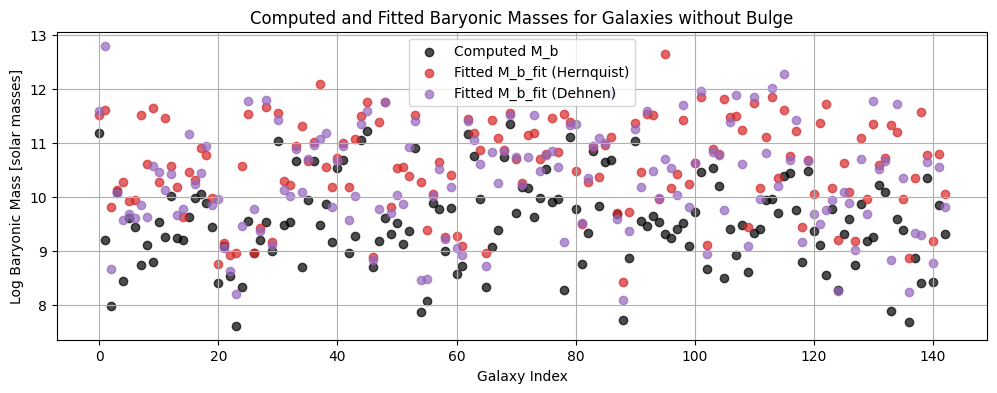

In [17]:
# for galaxies with bulge

data = pd.read_csv(os.path.join(data_path, "M_b_comparison.csv"))

data = data[~data["GalaxyID"].isin(gid_bulge)]

idx = np.arange(len(data))

plt.figure(figsize=(12,4))
plt.scatter(idx, data["log_M_b"], label='Computed M_b', color='k', alpha=0.7)
plt.scatter(idx, data["log_M_b_fit_hern"], label='Fitted M_b_fit (Hernquist)', color='C3', alpha=0.7)
plt.scatter(idx, data["log_M_b_fit_dehnen"], label='Fitted M_b_fit (Dehnen)', color='C4', alpha=0.7)
plt.xlabel('Galaxy Index')
plt.ylabel('Log Baryonic Mass [solar masses]')
plt.title('Computed and Fitted Baryonic Masses for Galaxies without Bulge')
plt.legend()
plt.grid()
plt.show()

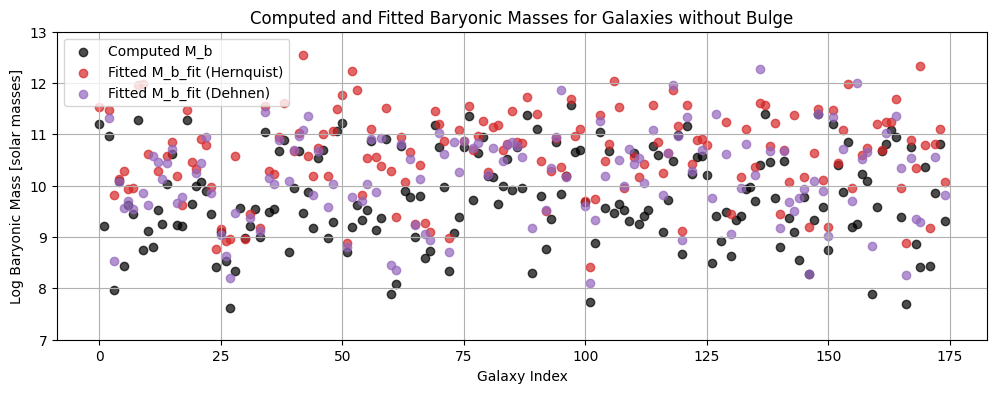

In [35]:
# for galaxies without bulge
data = pd.read_csv(os.path.join(data_path, "M_b_comparison.csv"))

# data = data[data["GalaxyID"].isin(gid_nobulge)]

# data = data[(data["log_M_b_fit_hern"] < 13) & (data["log_M_b_fit_dehnen"] < 13)]

idx = np.arange(len(data))

plt.figure(figsize=(12,4))
plt.scatter(idx, data["log_M_b"], label='Computed M_b', color='k', alpha=0.7)
plt.scatter(idx, data["log_M_b_fit_hern"], label='Fitted M_b_fit (Hernquist)', color='C3', alpha=0.7)
plt.scatter(idx, data["log_M_b_fit_dehnen"], label='Fitted M_b_fit (Dehnen)', color='C4', alpha=0.7)
plt.xlabel('Galaxy Index')
plt.ylabel('Log Baryonic Mass [solar masses]')
plt.title('Computed and Fitted Baryonic Masses for Galaxies without Bulge')
plt.legend()
plt.grid()
plt.ylim(7,13)
plt.show()

Fitted M_b is systematically larger, even for galaxies without a bulge componenet. 

# Checking new log generated data with no failed galaxies 

In [26]:
data_path = os.getcwd() + "/data/fit_data/"

df = pd.read_csv(data_path + "hern_fits.csv")
dfd = pd.read_csv(data_path + "dehnen_fits.csv")

df.head()

,GalaxyID,M_b_fit,a_fit,ChiSq,M_b_fit_bulge,a_fit_bulge,ChiSq_bulge
0,NGC5371,3.379071e+11,10.718281,5220.849667,NaN,NaN,NaN
1,UGC05829,4.094936e+11,100.000000,218.915833,NaN,NaN,NaN
2,NGC5005,3.038745e+11,7.392096,1667.229288,1.502302e+10,0.407524,1970.014208
3,UGCA444,6.685526e+09,13.210223,133.680930,NaN,NaN,NaN
4,NGC1003,1.379919e+10,3.716879,364.923466,NaN,NaN,NaN


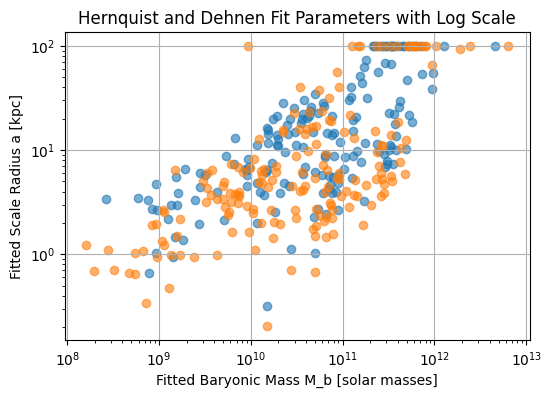

In [27]:
plt.figure(figsize=(6,4))

plt.scatter(df["M_b_fit"].values, df["a_fit"].values, color='C0', alpha=0.6)
plt.scatter(dfd["M_b_fit"].values, dfd["a_fit"].values, color='C1', alpha=0.6)
plt.xlabel('Fitted Baryonic Mass M_b [solar masses]')
plt.ylabel('Fitted Scale Radius a [kpc]')
plt.title('Hernquist and Dehnen Fit Parameters with Log Scale')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.show()

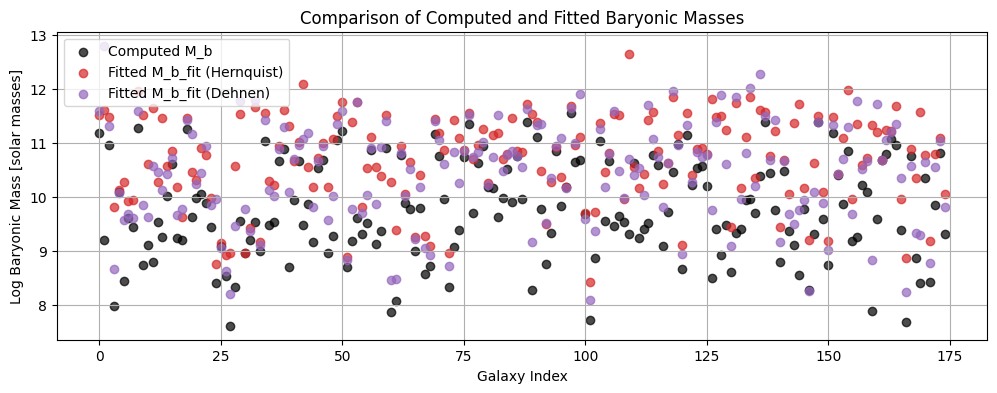

In [40]:
data = pd.read_csv(os.path.join(data_path, "M_b_comparison.csv"))

# data = data[data['log_M_b_fit'] < 20]

idx = np.arange(len(data))

plt.figure(figsize=(12,4))
plt.scatter(idx, data["log_M_b"], label='Computed M_b', color='k', alpha=0.7)
plt.scatter(idx, data["log_M_b_fit_hern"], label='Fitted M_b_fit (Hernquist)', color='C3', alpha=0.7)
plt.scatter(idx, data["log_M_b_fit_dehnen"], label='Fitted M_b_fit (Dehnen)', color='C4', alpha=0.7)
plt.xlabel('Galaxy Index')
plt.ylabel('Log Baryonic Mass [solar masses]')
plt.title('Comparison of Computed and Fitted Baryonic Masses')
plt.legend()
plt.grid()
plt.show()

Number of galaxies in comparison: 175


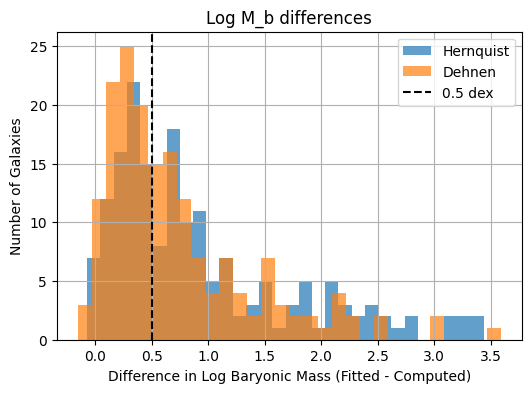

In [28]:
# hist of the differences between computed and fitted M_b values
data = pd.read_csv(os.path.join(data_path, "M_b_comparison.csv"))
# data = data[(data["log_M_b_fit_hern"] < 20) & (data["log_M_b_fit_dehnen"] < 20)]
print("Number of galaxies in comparison:", len(data))
data["M_b_diff_hern"] = data["log_M_b_fit_hern"] - data["log_M_b"]
data["M_b_diff_dehnen"] = data["log_M_b_fit_dehnen"] - data["log_M_b"]

plt.figure(figsize=(6,4))
plt.hist(data["M_b_diff_hern"], bins=30, color='C0', alpha=0.7, label='Hernquist')
plt.hist(data["M_b_diff_dehnen"], bins=30, color='C1', alpha=0.7, label='Dehnen')
plt.axvline(0.5, color='k', linestyle='--', label='0.5 dex')
plt.xlabel('Difference in Log Baryonic Mass (Fitted - Computed)')
plt.ylabel('Number of Galaxies')
plt.title('Log M_b differences')
plt.legend()
plt.grid()
plt.show()

Number of galaxies in comparison: 143


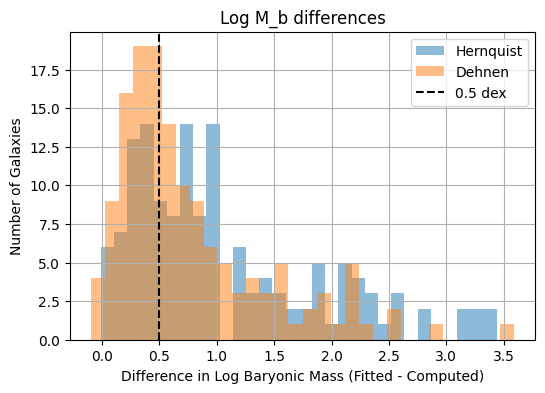

In [39]:
# hist of the differences between computed and fitted M_b values
data = pd.read_csv(os.path.join(data_path, "M_b_comparison.csv"))

# no bulge 

data = data[~data["GalaxyID"].isin(gid_bulge)]

data = data[(data["log_M_b_fit_hern"] < 20) & (data["log_M_b_fit_dehnen"] < 20)]
print("Number of galaxies in comparison:", len(data))
data["M_b_diff_hern"] = data["log_M_b_fit_hern"] - data["log_M_b"]
data["M_b_diff_dehnen"] = data["log_M_b_fit_dehnen"] - data["log_M_b"]

plt.figure(figsize=(6,4))
plt.hist(data["M_b_diff_hern"], bins=30, color='C0', alpha=0.5, label='Hernquist')
plt.hist(data["M_b_diff_dehnen"], bins=30, color='C1', alpha=0.5, label='Dehnen')
plt.axvline(0.5, color='k', linestyle='--', label='0.5 dex')
plt.xlabel('Difference in Log Baryonic Mass (Fitted - Computed)')
plt.ylabel('Number of Galaxies')
plt.title('Log M_b differences')
plt.legend()
plt.grid()
plt.show()

In [29]:
len(data[data["M_b_diff_hern"] <= 0.5])
len(data[data["M_b_diff_dehnen"] <= 0.5])

print("Number of galaxies with Hernquist M_b fit within 0.5 dex of computed M_b:", len(data[data["M_b_diff_hern"] <= 0.5]))
print("Number of galaxies with Dehnen M_b fit within 0.5 dex of computed M_b:", len(data[data["M_b_diff_dehnen"] <= 0.5]))

Number of galaxies with Hernquist M_b fit within 0.5 dex of computed M_b: 68
Number of galaxies with Dehnen M_b fit within 0.5 dex of computed M_b: 86


# Dehnen Fits

In [3]:
plot_path = os.getcwd() + "/plots/fits/"
data_path = os.getcwd() + "/data/fit_data/"

gamma_data = pd.read_csv(data_path + "gamma_fits.csv")

results = []
failed = []

for galaxy_id in galaxy_ids: 
    gamma_s, gamma_b = gamma_data[gamma_data["GalaxyID"] == galaxy_id][["Gamma_disk", "Gamma_bulge"]].values[0]
    try:
        fitter = DehnenFit(galaxy_id, gamma_star=gamma_s, gamma_bulge=gamma_b, method="lmfit")
        M_b_fit, a_fit, gamma_fit = fitter.M_b_fit, fitter.a_fit, fitter.gamma_fit
        chisqr = fitter.error
        
        M_b_fit_b, a_fit_b, gamma_fit_b = fitter.M_b_fit_bulge, fitter.a_fit_bulge, fitter.gamma_fit_bulge
        chisqr_b = fitter.error_bulge
    except Exception as e:
        failed.append(galaxy_id)
        print(f"Error fitting galaxy {galaxy_id}. Skipping...")
        continue
    
    results.append([galaxy_id, M_b_fit, a_fit, gamma_fit, chisqr, M_b_fit_b, a_fit_b, gamma_fit_b, chisqr_b])
    
    # r_vals = fitter.r_vals
    # rmax = r_vals.max() * 2 # kpc
    # ri = np.geomspace(0.1, rmax, 100)
    
    # vc_dg_data = fitter.vc_disk_gas
    # vc_bulge_data = fitter.vc_bulge
    
    # vc_dg_model = fitter.vc(ri, M_b=M_b_fit, a=a_fit, gamma=gamma_fit)
    # vc_bulge_model = fitter.vc(ri, M_b=M_b_fit_b, a=a_fit_b, gamma=gamma_fit_b)
    
    
    # plt.figure(figsize=(6,4))

    # plt.scatter(r_vals, vc_dg_data, label='Disk+Gas', color='C0', s=10)
    # plt.plot(ri, vc_dg_model, label='Disk+Gas Dehnen', color='C0', alpha=0.7)
    # plt.scatter(r_vals, vc_bulge_data, label='Bulge', color='C1', s=10)
    # plt.plot(ri, vc_bulge_model, label='Bulge Dehnen', color='C1', alpha=0.7)
    # plt.xlabel('Radius (kpc)')
    # plt.ylabel('Velocity (km/s)')
    # plt.title(f'Dehnen Fit for Galaxy {galaxy_id}')
    # plt.legend(fontsize=6, loc="lower right")
    # plt.grid()
    # # plt.savefig(plot_path + f"disk-bulge-gas/{galaxy_id}_disk_gas_bulge_fit_Dehnen.png")
    # plt.show()
    
    
results_df = pd.DataFrame(results, columns=["GalaxyID", "M_b_fit", "a_fit", "gamma_fit", "ChiSq", "M_b_fit_bulge", "a_fit_bulge", "gamma_fit_bulge", "ChiSq_bulge"])
results_df.to_csv(os.path.join(data_path, "dehnen_fits_min.csv"), index=False)
print("Fitting complete. Results saved.")
# np.savetxt(os.path.join(data_path, "dehnen-failed.txt"), failed, fmt="%s")
print("Number of failed fits:", len(failed))

Fitting with lmfit took 0.0160 seconds
Fitted parameters for galaxy NGC5371 using lmfit:
  M_b = 3.99e+11 solar masses
  a   = 18.76 kpc
  gamma = 1.42
  chi-squared = 4703.1967
Fitting with lmfit took 0.0552 seconds
Fitted parameters for galaxy UGC05829 using lmfit:
  M_b = 6.40e+12 solar masses
  a   = 100.00 kpc
  gamma = 0.12
  chi-squared = 16.6812
Fitting with lmfit took 0.0175 seconds
Fitted parameters for galaxy NGC5005 using lmfit:
  M_b = 2.05e+11 solar masses
  a   = 2.95 kpc
  gamma = 0.05
  chi-squared = 364.3185
Bulge component detected, performing separate fit for bulge...
Fitting with lmfit took 0.0173 seconds
Fitted parameters for galaxy NGC5005 using lmfit:
  M_b = 1.49e+10 solar masses
  a   = 0.25 kpc
  gamma = 0.00
  chi-squared = 1750.4356
Fitting with lmfit took 0.0231 seconds
Fitted parameters for galaxy UGCA444 using lmfit:
  M_b = 9.17e+08 solar masses
  a   = 1.95 kpc
  gamma = 0.00
  chi-squared = 63.4906
Fitting with lmfit took 0.0190 seconds
Fitted paramet

Fitting with lmfit took 0.0297 seconds
Fitted parameters for galaxy NGC0100 using lmfit:
  M_b = 5.77e+09 solar masses
  a   = 2.53 kpc
  gamma = 0.00
  chi-squared = 38.9536
Fitting with lmfit took 0.0293 seconds
Fitted parameters for galaxy UGC07261 using lmfit:
  M_b = 5.59e+09 solar masses
  a   = 2.40 kpc
  gamma = 0.00
  chi-squared = 37.4732
Fitting with lmfit took 0.0264 seconds
Fitted parameters for galaxy NGC6195 using lmfit:
  M_b = 4.92e+11 solar masses
  a   = 12.62 kpc
  gamma = 0.00
  chi-squared = 1540.9452
Bulge component detected, performing separate fit for bulge...
Fitting with lmfit took 0.0231 seconds
Fitted parameters for galaxy NGC6195 using lmfit:
  M_b = 1.06e+11 solar masses
  a   = 1.27 kpc
  gamma = 0.00
  chi-squared = 884.2838
Fitting with lmfit took 0.0212 seconds
Fitted parameters for galaxy UGC01281 using lmfit:
  M_b = 7.20e+09 solar masses
  a   = 6.88 kpc
  gamma = 0.34
  chi-squared = 45.1141
Fitting with lmfit took 0.0225 seconds
Fitted parameters

In [48]:
galaxy_mb_passed = ['NGC5371', 'NGC5005', 'NGC1003', 'NGC0100', 'UGC07261', 'NGC6195',
       'NGC4183', 'UGC08699', 'F583-4', 'NGC2841', 'NGC2403', 'NGC0300',
       'NGC4214', 'PGC51017', 'NGC2915', 'UGC08490', 'UGC05721',
       'ESO563-G021', 'ESO116-G012', 'NGC3521', 'NGC1090', 'NGC3893',
       'NGC3726', 'UGC12506', 'UGC11455', 'NGC1705', 'UGC06818',
       'UGC05253', 'UGC03546', 'NGC6503', 'UGC07690', 'UGC00634',
       'DDO154', 'UGC07603', 'NGC3992', 'NGC4088', 'ESO444-G084',
       'NGC5055', 'NGC0801', 'NGC6946', 'UGC06614', 'NGC3769', 'NGC4085',
       'NGC3198', 'NGC5033', 'UGC02885', 'NGC5907', 'NGC0289', 'UGC06973',
       'UGC02487', 'UGC09037', 'F571-8', 'D564-8', 'NGC2998', 'NGC2683',
       'NGC5585', 'NGC7814', 'UGC11914', 'NGC0891', 'UGC06787', 'D631-7',
       'NGC2955', 'UGC03580', 'NGC4100', 'UGC06786', 'NGC6674', 'NGC6015',
       'DDO168', 'NGC2903', 'UGC02455', 'UGC05986', 'UGCA281', 'UGC09133',
       'NGC0024', 'UGC08550', 'UGC02953', 'NGC4138', 'NGC4559', 'NGC4013',
       'UGC03205', 'NGC7331', 'UGC02916', 'NGC4217', 'NGC3949', 'D512-2',
       'NGC4157']

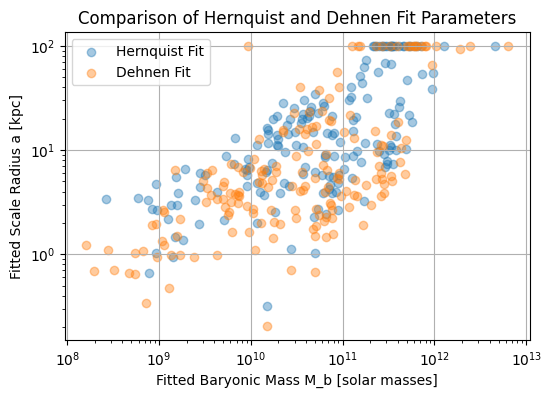

In [4]:
data_path = os.getcwd() + "/data/fit_data/"

dfh = pd.read_csv(data_path + "hern_fits.csv")
# dfht = pd.read_csv(data_path + "hern_fits_test.csv")
dfd = pd.read_csv(data_path + "dehnen_fits_min.csv")
# dfdt = pd.read_csv(data_path + "dehnen-fits-test.csv")

plt.figure(figsize=(6,4))
plt.scatter(dfh["M_b_fit"].values, dfh["a_fit"].values, color='C0', alpha=0.4, label='Hernquist Fit')
# plt.scatter(dfht["M_b_fit"].values, dfht["a_fit"].values, color='C3', alpha=0.4, label='Hernquist Fit (Test)')
plt.scatter(dfd["M_b_fit"].values, dfd["a_fit"].values, color='C1', alpha=0.4, label='Dehnen Fit')
# plt.scatter(dfdt["M_b_fit"].values, dfdt["a_fit"].values, color='C2', alpha=0.4, label='Dehnen Fit (Test)')
plt.xlabel('Fitted Baryonic Mass M_b [solar masses]')
plt.ylabel('Fitted Scale Radius a [kpc]')
plt.title('Comparison of Hernquist and Dehnen Fit Parameters')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

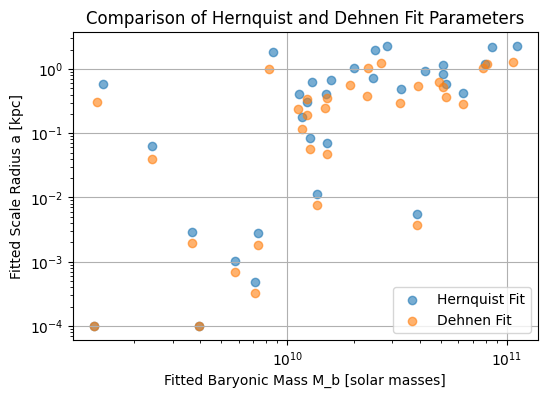

In [5]:
plt.figure(figsize=(6,4))
plt.scatter(dfh["M_b_fit_bulge"].values, dfh["a_fit_bulge"].values, color='C0', alpha=0.6, label='Hernquist Fit')
plt.scatter(dfd["M_b_fit_bulge"].values, dfd["a_fit_bulge"].values, color='C1', alpha=0.6, label='Dehnen Fit')
plt.xlabel('Fitted Baryonic Mass M_b [solar masses]')
plt.ylabel('Fitted Scale Radius a [kpc]')
plt.title('Comparison of Hernquist and Dehnen Fit Parameters')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

In [12]:
# df without nan values
dfh_clean = dfh.dropna(subset=["M_b_fit", "a_fit"])
dfd_clean = dfd.dropna(subset=["M_b_fit", "a_fit"])

print("Hern length:", len(dfh_clean))
print("Dehnen length:", len(dfd_clean))

Hern length: 175
Dehnen length: 144


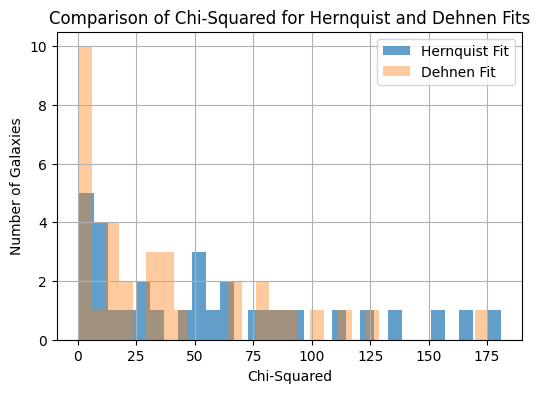

In [49]:
dfh = pd.read_csv(data_path + "hern_fits.csv")
dfd = pd.read_csv(data_path + "dehnen_fits.csv")

plt.figure(figsize=(6,4))

# subh = dfh[dfh["ChiSq"] < 100]
# subd = dfd[dfd["ChiSq"] < 100]

subh = dfh[dfh["GalaxyID"].isin(galaxy_mb_passed)]
subd = dfd[dfd["GalaxyID"].isin(galaxy_mb_passed)]

subh = subh[subh["ChiSq"] < 200]
subd = subd[subd["ChiSq"] < 200]

plt.hist(subh["ChiSq"].values, bins=30, color='C0', density=False, alpha=0.7, label='Hernquist Fit')
plt.hist(subd["ChiSq"].values, bins=30, color='C1', density=False, alpha=0.4, label='Dehnen Fit')
plt.xlabel('Chi-Squared')
plt.ylabel('Number of Galaxies')
plt.title('Comparison of Chi-Squared for Hernquist and Dehnen Fits')
plt.legend()
plt.grid()
plt.show()

Galaxy NGC5371: Chi-Hernquist = 5220.85, Chi-Dehnen = 4703.20, Difference = 517.65


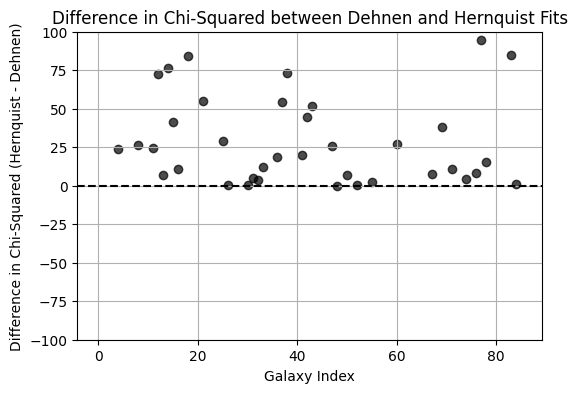

In [59]:
dfh = pd.read_csv(data_path + "hern_fits.csv")
dfd = pd.read_csv(data_path + "dehnen_fits.csv")

plt.figure(figsize=(6,4))

# subh = dfh[dfh["ChiSq"] < 100]
# subd = dfd[dfd["ChiSq"] < 100]

subh = dfh[dfh["GalaxyID"].isin(galaxy_mb_passed)]
subd = dfd[dfd["GalaxyID"].isin(galaxy_mb_passed)]

for i, gid in enumerate(galaxy_mb_passed):
    
    chi_h = subh[subh["GalaxyID"] == gid]["ChiSq"].values[0]
    chi_d = subd[subd["GalaxyID"] == gid]["ChiSq"].values[0]
    diff = chi_h - chi_d
    if i == 0:
        print(f"Galaxy {gid}: Chi-Hernquist = {chi_h:.2f}, Chi-Dehnen = {chi_d:.2f}, Difference = {diff:.2f}")
    plt.scatter(i, diff, color='k', alpha=0.7)
    
    
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Galaxy Index')
plt.ylabel('Difference in Chi-Squared (Hernquist - Dehnen)')
plt.title('Difference in Chi-Squared between Dehnen and Hernquist Fits')
plt.ylim(-100, 100)
plt.grid()
plt.show()

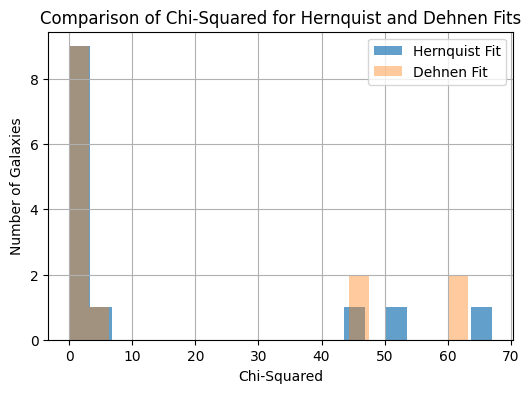

In [8]:
dfh = pd.read_csv(data_path + "hern_fits.csv")
dfd = pd.read_csv(data_path + "dehnen_fits_min.csv")

plt.figure(figsize=(6,4))

subh = dfh[dfh["ChiSq_bulge"] < 100]
subd = dfd[dfd["ChiSq_bulge"] < 100]

plt.hist(subh["ChiSq_bulge"].values, bins=20, color='C0', density=False, alpha=0.7, label='Hernquist Fit')
plt.hist(subd["ChiSq_bulge"].values, bins=20, color='C1', density=False, alpha=0.4, label='Dehnen Fit')
plt.xlabel('Chi-Squared')
plt.ylabel('Number of Galaxies')
plt.title('Comparison of Chi-Squared for Hernquist and Dehnen Fits')
plt.legend()
plt.grid()
plt.show()

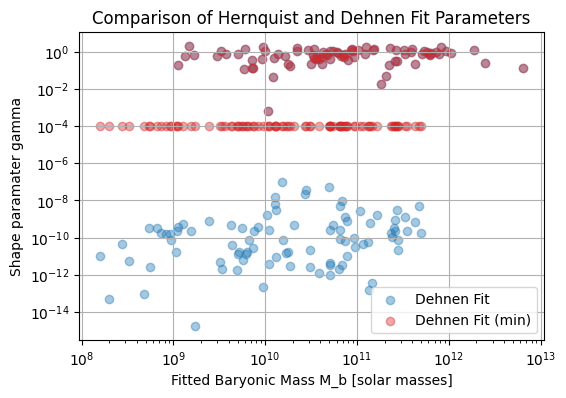

In [9]:
data_path = os.getcwd() + "/data/fit_data/"

dfh = pd.read_csv(data_path + "dehnen_fits.csv")
# dfht = pd.read_csv(data_path + "hern_fits_test.csv")
dfd = pd.read_csv(data_path + "dehnen_fits_min.csv")
# dfdt = pd.read_csv(data_path + "dehnen-fits-test.csv")

plt.figure(figsize=(6,4))
plt.scatter(dfh["M_b_fit"].values, dfh["gamma_fit"].values, color='C0', alpha=0.4, label='Dehnen Fit')
plt.scatter(dfd["M_b_fit"].values, dfd["gamma_fit"].values, color='C3', alpha=0.4, label='Dehnen Fit (min)')
# plt.scatter(dfd["M_b_fit"].values, dfd["gamma_fit"].values, color='C1', alpha=0.4, label='Dehnen Fit')
# plt.scatter(dfdt["M_b_fit"].values, dfdt["a_fit"].values, color='C2', alpha=0.4, label='Dehnen Fit (Test)')
plt.xlabel('Fitted Baryonic Mass M_b [solar masses]')
plt.ylabel('Shape paramater gamma')
plt.title('Comparison of Hernquist and Dehnen Fit Parameters')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

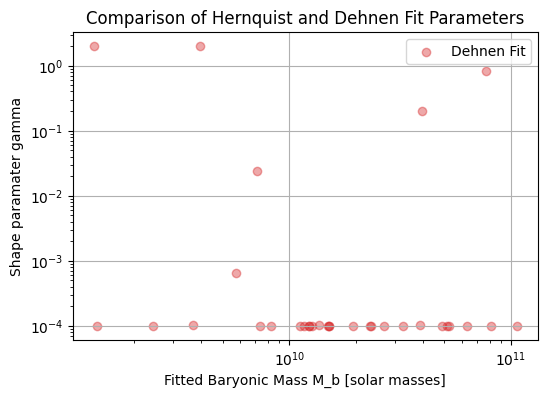

In [11]:
dfh = pd.read_csv(data_path + "hern_fits.csv")
# dfht = pd.read_csv(data_path + "hern_fits_test.csv")
dfd = pd.read_csv(data_path + "dehnen_fits.csv")
# dfdt = pd.read_csv(data_path + "dehnen-fits-test.csv")

plt.figure(figsize=(6,4))
# plt.scatter(dfh["M_b_fit_bulge"].values, dfh["gamma_fit_bulge"].values, color='C0', alpha=0.4, label='Hernquist Fit')
plt.scatter(dfd["M_b_fit_bulge"].values, dfd["gamma_fit_bulge"].values, color='C3', alpha=0.4, label='Dehnen Fit')
# plt.scatter(dfd["M_b_fit"].values, dfd["gamma_fit"].values, color='C1', alpha=0.4, label='Dehnen Fit')
# plt.scatter(dfdt["M_b_fit"].values, dfdt["a_fit"].values, color='C2', alpha=0.4, label='Dehnen Fit (Test)')
plt.xlabel('Fitted Baryonic Mass M_b [solar masses]')
plt.ylabel('Shape paramater gamma')
plt.title('Comparison of Hernquist and Dehnen Fit Parameters')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

In [28]:
np.log10(2)

np.float64(0.3010299956639812)

<Axes: >

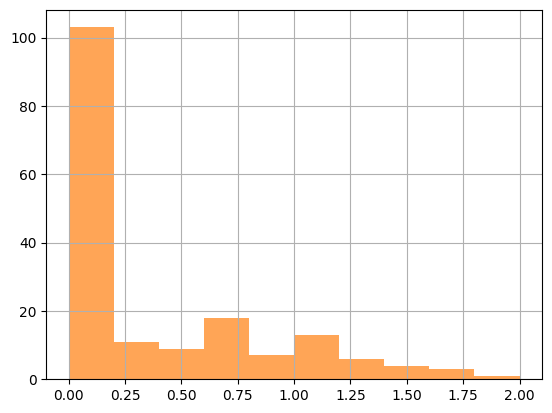

In [12]:
# dfh['gamma_fit'].hist(bins=10, color='C0', alpha=0.7)
dfd['gamma_fit'].hist(bins=10, color='C1', alpha=0.7)

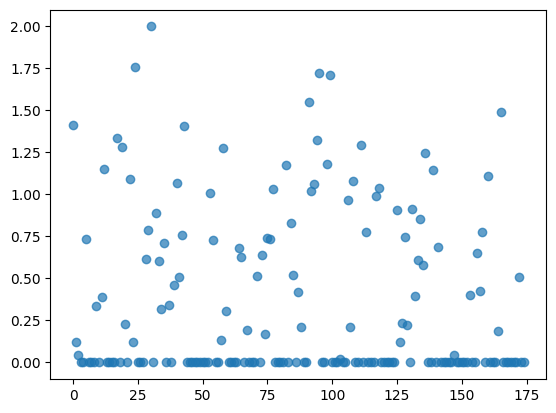

In [13]:
plt.scatter(range(len(dfd)), dfd['gamma_fit'].values, color='C0', alpha=0.7)

# Comparison Fits Hern and Dehnen

In [2]:
G = 4.30091e-6  # [kpc * (km/s)^2 / solar mass]

# Hernquist model for circular velocity for fitting
def hernquist_model(r, log_M_b=10, log_a=1):
    """
    Circular velocity squared for Hernquist profile.
    Takes:
        r : radius [kpc] (or array of radii)
        log_M_b : log10 of total baryonic mass [solar masses]
        log_a : log10 of scale radius [kpc]
    Returns:
        Vc : circular velocity at radius r [km/s]
    """
    Mb = 10**log_M_b  # convert log10(M_b) to M_b in solar masses
    a = 10**log_a  # convert log10(a) to a in kpc
    vc = np.sqrt(G * Mb * r) / (r + a)
    return vc

# Dehnen model for circular velocity for fitting
def dehnen_model(r, log_M_b=10, log_a=1, gamma=1):
    """
    Circular velocity squared for Dehnen profile.
    Takes:
        r : radius [kpc] (or array of radii)
        log_M_b : log10 of total baryonic mass [solar masses]
        log_a : log10 of scale radius [kpc]
        gamma : inner slope parameter
    Returns:
        Vc : circular velocity at radius r [km/s]
    """
    Mb = 10**log_M_b  # convert log10(M_b) to M_b in solar masses
    a = 10**log_a  # convert log10(a) to a in kpc
    vcsq = G * Mb * ((r ** (2 - gamma)) / (r + a) ** (3 - gamma))
    return np.sqrt(vcsq)

In [3]:
def vc_disk_gas(data, gamma_star=0.5):
    """
    Total baryonic circular velocity.
    Takes:
        data : dataframe with columns 'Vdisk', 'Vbul', 'Vgas'
        gamma_star : mass-to-light ratio scaling factor for disk
    Returns:
        vc_baryons : total baryonic circular velocity [km/s]
        radii : radius [kpc]
    """
    radii = data["Rad"].values
    vc_disk_sq = gamma_star * data["Vdisk"] ** 2
    vc_gas_sq = data["Vgas"] ** 2

    vc_baryons = np.sqrt(vc_disk_sq + vc_gas_sq)

    return radii, vc_baryons

def vc_bulge(data, gamma_bulge=0.7):
    """
    Bulge circular velocity.
    Takes:
        data : dataframe with columns 'Vbul'
        gamma_bulge : mass-to-light ratio scaling factor for bulge
    Returns:
        vc_bulge : bulge circular velocity [km/s]
        radii : radius [kpc]
    """
    radii = data["Rad"].values
    vc_bulge = np.sqrt(gamma_bulge * data["Vbul"] ** 2)

    return radii, vc_bulge

In [4]:
data_path = os.getcwd() + "/../data/fit_data/"
dfh = pd.read_csv(data_path + "hern_fits.csv")
dfd = pd.read_csv(data_path + "dehnen_fits.csv")
# print("Hernquist fit data length:", len(dfh))
# print("Dehnen fit data length:", len(dfd))
# # drop nans
# dfh = dfh.dropna(subset=["M_b_fit", "a_fit"])
# dfd = dfd.dropna(subset=["M_b_fit", "a_fit"])
# print("Hernquist fit data length after dropping NaNs:", len(dfh))
# print("Dehnen fit data length after dropping NaNs:", len(dfd))
# # no bulge 
# dfh = dfh[~dfh["GalaxyID"].isin(gid_bulge)]
# dfd = dfd[~dfd["GalaxyID"].isin(gid_bulge)]
# print("Hernquist fit data length without bulge galaxies:", len(dfh))
# print("Dehnen fit data length without bulge galaxies:", len(dfd))

print("Hernquist fit data length:", len(dfh))
print("Dehnen fit data length:", len(dfd))

Hernquist fit data length: 175
Dehnen fit data length: 175


In [5]:
# galaxy IDs in both fits
galaxy_ids_fit = set(dfh["GalaxyID"].values) & set(dfd["GalaxyID"].values)
print("Number of unique galaxies in fits:", len(galaxy_ids_fit))

Number of unique galaxies in fits: 175


In [18]:
galaxy_ids_fit = list(galaxy_ids_fit)

In [39]:
galaxy_id_fit = ['NGC5371', 'NGC5005', 'NGC1003', 'NGC0100', 'UGC07261', 'NGC6195',
       'NGC4183', 'UGC08699', 'F583-4', 'NGC2841', 'NGC2403', 'NGC0300',
       'NGC4214', 'PGC51017', 'NGC2915', 'UGC08490', 'UGC05721',
       'ESO563-G021', 'ESO116-G012', 'NGC3521', 'NGC1090', 'NGC3893',
       'NGC3726', 'UGC12506', 'UGC11455', 'NGC1705', 'UGC06818',
       'UGC05253', 'UGC03546', 'NGC6503', 'UGC07690', 'UGC00634',
       'DDO154', 'UGC07603', 'NGC3992', 'NGC4088', 'ESO444-G084',
       'NGC5055', 'NGC0801', 'NGC6946', 'UGC06614', 'NGC3769', 'NGC4085',
       'NGC3198', 'NGC5033', 'UGC02885', 'NGC5907', 'NGC0289', 'UGC06973',
       'UGC02487', 'UGC09037', 'F571-8', 'D564-8', 'NGC2998', 'NGC2683',
       'NGC5585', 'NGC7814', 'UGC11914', 'NGC0891', 'UGC06787', 'D631-7',
       'NGC2955', 'UGC03580', 'NGC4100', 'UGC06786', 'NGC6674', 'NGC6015',
       'DDO168', 'NGC2903', 'UGC02455', 'UGC05986', 'UGCA281', 'UGC09133',
       'NGC0024', 'UGC08550', 'UGC02953', 'NGC4138', 'NGC4559', 'NGC4013',
       'UGC03205', 'NGC7331', 'UGC02916', 'NGC4217', 'NGC3949', 'D512-2',
       'NGC4157']

type(galaxy_id_fit)

list

In [5]:
gravo_list = ["DDO154", "ESO444-G084", "F568-V1", "F574-1", "NGC0300", "NGC3109", "UGC00128", "UGC06446", "UGC06667", "UGC08286", "NGC4376", "NGC4396", "NGC7320", "UGC04169"]

gamma_data = pd.read_csv(data_path + "gamma_fits.csv")

In [6]:
plot_path = os.getcwd() + "/../plots/fits/gravo/"

for galaxy_id in gravo_list:
    print(f"Plotting galaxy {galaxy_id}...")
    try:
        gamma_s = gamma_data[gamma_data["GalaxyID"] == galaxy_id]["Gamma_disk"].values[0]
        gamma_d = gamma_data[gamma_data["GalaxyID"] == galaxy_id]["Gamma_bulge"].values[0]
        data, _, _ = get_rc_data(galaxy_id)
        r_vals, vc_baryons = vc_disk_gas(data, gamma_star=gamma_s)
        
        bulge = False
        if np.sum(data["Vbul"].values) > 0:
            _, vc_bul = vc_bulge(data, gamma_bulge=gamma_d)
            bulge = True
        
        subh = dfh[dfh["GalaxyID"] == galaxy_id]
        subd = dfd[dfd["GalaxyID"] == galaxy_id]
        
        log_M_b_h = np.log10(subh["M_b_fit"].values[0])
        log_a_h = np.log10(subh["a_fit"].values[0])
        
        log_M_b_d = np.log10(subd["M_b_fit"].values[0])
        log_a_d = np.log10(subd["a_fit"].values[0])
        gamma_d = subd["gamma_fit"].values[0]
        
        ri = np.geomspace(0.1, r_vals.max() * 2, 100)
        vc_h = hernquist_model(ri, log_M_b=log_M_b_h, log_a=log_a_h)
        vc_d = dehnen_model(ri, log_M_b=log_M_b_d, log_a=log_a_d, gamma=gamma_d)
        
        if bulge:
            log_M_b_h_b = np.log10(subh["M_b_fit_bulge"].values[0])
            log_a_h_b = np.log10(subh["a_fit_bulge"].values[0])
            log_M_b_d_b = np.log10(subd["M_b_fit_bulge"].values[0])
            log_a_d_b = np.log10(subd["a_fit_bulge"].values[0])
            gamma_d_b = subd["gamma_fit_bulge"].values[0]
            vc_d_b = dehnen_model(ri, log_M_b=log_M_b_d_b, log_a=log_a_d_b, gamma=gamma_d_b)
            vc_h_b = hernquist_model(ri, log_M_b=log_M_b_h_b, log_a=log_a_h_b)

        ymax = max(vc_baryons.max(), vc_h.max(), vc_d.max()) * 1.2
        
        plt.figure(figsize=(6,4))
        plt.scatter(r_vals, vc_baryons, label='Baryonic Data', color='k', s=10)
        plt.plot(ri, vc_h, label='Hernquist Disk + Gas', color='C0', alpha=0.7)
        plt.plot(ri, vc_d, label='Dehnen Disk + Gas', color='C1', alpha=0.7)
        if bulge:
            plt.scatter(r_vals, vc_bul, label='Bulge Data', color='grey', s=10)
            plt.plot(ri, vc_h_b, label='Hernquist Bulge', color='C0', linestyle='--', alpha=0.7)
            plt.plot(ri, vc_d_b, label='Dehnen Bulge', color='C1', linestyle='--', alpha=0.7)
        plt.xlabel('Radius (kpc)')
        plt.ylabel('Circular Velocity (km/s)')
        plt.title(f'Galaxy {galaxy_id} - Hernquist vs Dehnen Fit')
        plt.legend(fontsize=6)
        plt.ylim(0, ymax)
        plt.grid()
        plt.savefig(plot_path + f"{galaxy_id}_rc_fits.png")
        plt.close()
        # plt.show()
    except Exception as e:
        print(f"Error plotting galaxy {galaxy_id}: {e}")
        continue

Plotting galaxy DDO154...
Plotting galaxy ESO444-G084...
Plotting galaxy F568-V1...
Plotting galaxy F574-1...
Plotting galaxy NGC0300...
Plotting galaxy NGC3109...
Plotting galaxy UGC00128...
Plotting galaxy UGC06446...
Plotting galaxy UGC06667...
Plotting galaxy UGC08286...
Plotting galaxy NGC4376...
Error plotting galaxy NGC4376: index 0 is out of bounds for axis 0 with size 0
Plotting galaxy NGC4396...
Error plotting galaxy NGC4396: index 0 is out of bounds for axis 0 with size 0
Plotting galaxy NGC7320...
Error plotting galaxy NGC7320: index 0 is out of bounds for axis 0 with size 0
Plotting galaxy UGC04169...
Error plotting galaxy UGC04169: index 0 is out of bounds for axis 0 with size 0


In [7]:
def phi_hern(M_b, a):
    G = 4.30091e-6  # [kpc * (km/s)^2/ solar mass]

    def phi_func(r, th):
        return -G * M_b / (r + a)

    return phi_func

def phi_dehen(M_b, a, gamma):
    G = 4.30091e-6  # [kpc * (km/s)^2/ solar mass]

    def phi_func(r, th):
        prefactor = - (G * M_b) / (a * (2 - gamma))
        return prefactor * ( 1 - (( r / (r+a) )**(2-gamma)) )

    return phi_func

In [8]:
for galaxy_id in gravo_list:
    gamma_s = gamma_data[gamma_data["GalaxyID"] == galaxy_id]["Gamma_disk"].values[0]
    data, _, _ = get_rc_data(galaxy_id)
    r_vals, vc_baryons = vc_disk_gas(data, gamma_star=gamma_s)
    
    subh = dfh[dfh["GalaxyID"] == galaxy_id]
    subd = dfd[dfd["GalaxyID"] == galaxy_id]
    
    M_b_h = subh["M_b_fit"].values[0]
    a_h = subh["a_fit"].values[0]
    
    M_b_d = subd["M_b_fit"].values[0]
    a_d = subd["a_fit"].values[0]
    gamma_d = subd["gamma_fit"].values[0]
    
    phi_H = phi_hern(M_b_h, a_h)
    phi_D = phi_dehen(M_b_d, a_d, gamma_d)

    ri = np.geomspace(0.1, 100, 100)

    phi_H_vals = np.abs(np.array([phi_H(r, 0) for r in ri]))
    phi_D_vals = np.abs(np.array([phi_D(r, 0) for r in ri]))
    percent_diff = 100 * ( np.abs((phi_H_vals - phi_D_vals)) / np.abs(phi_H_vals) )

    # plt.figure(figsize=(6,4))
    fig, axs = plt.subplots(2, 1, figsize=(6, 4), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    axs[0].plot(ri, phi_H_vals, label='Hernquist Potential', color='C0')
    axs[0].plot(ri, phi_D_vals, label='Dehnen Potential', color='C1')
    axs[0].set_ylabel('Potential (km^2/s^2)')
    axs[0].set_title(f'Gravitational Potential for Galaxy {galaxy_id}')
    axs[0].grid()
    axs[0].legend()
    axs[1].plot(ri, percent_diff, label='Percent Difference', color='C3')
    axs[1].set_xlabel('Radius (kpc)')
    axs[1].set_ylabel('Percent Difference (%)')
    plt.grid()
    axs[0].set_xscale('log')
    axs[0].set_yscale('log')
    axs[1].set_xscale('log')
    axs[1].set_ylim(0, 100)
    plt.tight_layout()
    plt.savefig(plot_path + f"{galaxy_id}_potential_fits.png")
    plt.close()

IndexError: index 0 is out of bounds for axis 0 with size 0

# BIC Between Hern and Dehnen

In [60]:
data_path = os.getcwd() + "/data/fit_data/"

dfh = pd.read_csv(data_path + "hern_fits.csv")
dfd = pd.read_csv(data_path + "dehnen_fits.csv")

# BIC criterion 
def BIC(galaxy_id):
    df, _, _ = get_rc_data(galaxy_id)
    N = len(df)
    chi2_h = dfh[dfh["GalaxyID"] == galaxy_id]["ChiSq"].values[0]
    chi2_d = dfd[dfd["GalaxyID"] == galaxy_id]["ChiSq"].values[0]
    k_h = 2  # M_b, a
    k_d = 3  # M_b, a, gamma
    
    bic_h = chi2_h + k_h * np.log(N)
    bic_d = chi2_d + k_d * np.log(N)
    return bic_h, bic_d

bic_results = []
for galaxy_id in galaxy_ids:
    bic_h, bic_d = BIC(galaxy_id)
    delta_bic = bic_h - bic_d # positive means Dehnen is better, negative means Hernquist is better
    bic_results.append((galaxy_id, bic_h, bic_d, delta_bic))
    
bic_df = pd.DataFrame(bic_results, columns=["GalaxyID", "BIC_Hernquist", "BIC_Dehnen", "Delta_BIC"])
bic_df.to_csv(os.path.join(data_path, "bic_comparison.csv"), index=False)

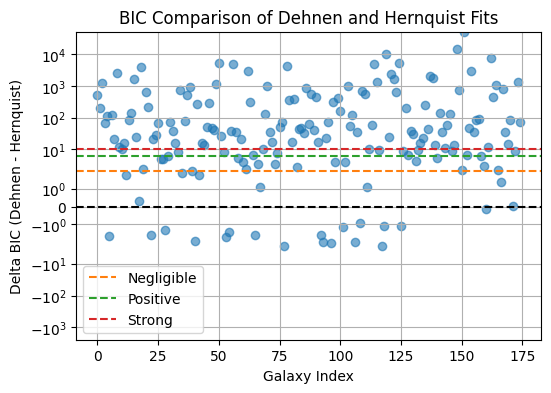

In [61]:
plt.figure(figsize=(6,4))
plt.scatter(range(len(bic_df)), bic_df["Delta_BIC"], color='C0', alpha=0.6)
plt.axhline(0, color='k', linestyle='--')
plt.axhline(2, color='C1', linestyle='--', label='Negligible')
plt.axhline(6, color='C2', linestyle='--', label='Positive')
plt.axhline(10, color='C3', linestyle='--', label='Strong')
plt.xlabel('Galaxy Index')
plt.ylabel('Delta BIC (Dehnen - Hernquist)')
plt.title('BIC Comparison of Dehnen and Hernquist Fits')
plt.yscale('symlog', linthresh=2)
# plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

In [66]:
len(bic_df[bic_df["Delta_BIC"] < 0])

18

In [21]:
# print galaxy IDs where Hernquist is preferred (Delta_BIC < 0)
hern_preferred = bic_df[bic_df["Delta_BIC"] < 0]["GalaxyID"].values
print("Galaxies where Hernquist fit is preferred:", hern_preferred)

Galaxies where Hernquist fit is preferred: ['UGC07559' 'F574-1' 'UGC07866' 'UGC06930' 'F561-1' 'UGC06818' 'UGC07690'
 'F563-1' 'UGC09992' 'UGC04499' 'UGC06973' 'D564-8' 'UGC12632' 'NGC5585'
 'F568-V1' 'ESO079-G014' 'UGC00128' 'UGC06628']


UGC07559: cut by length 
UGC07866: cut by length 
UGC06930: 9 points bad shape, probabaly cut 
UGC06818: cut by length 
UGC07690: cut by length 
UGC09992: cut by length 
UGC04499: 9 points no turndown 
UGC06973: Hernquist actually appears better for Disk+Gas and Bulge...
UGC12632: Only linearly rising
UGC00128: Bad shape, poor fit
UGC06628: cut by legnth 
F574-1: rising 
F561-1: cut by length
F563-1: rising 
F568-V1: cut by length 
D564-8: Dehen looks better but this will be cut anyhow. 
NGC5585: Very slightly better... 
ESO079-G014: only rising 